# Multi-Scale Modelling of Biological Systems Computer Practical 4 - Part II

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

## Step 1: Represent the data

In [17]:

model1 = np.array([
    [0.971, 0.04, -0.046, 0.141, -0.159],
    [0.988, 0.017, -0.068, 0.073, -0.131],
    [0.102, 0.155, 0.973, -0.084, 0.09],
    [0.089, 0.992, -0.031, -0.067, -0.072],
    [0.144, 0.975, -0.027, -0.061, -0.142],
])

model2 = np.array([
    [-0.267, -0.215, -0.032, -0.088, -0.189, -0.895, -0.175],
    [0.113, 0.293, 0.401, 0.783, -0.137, -0.26, -0.097],
    [0.932, -0.072, -0.073, -0.188, 0.236, 0.079, 0.089],
    [0.067, -0.087, 0.185, -0.157, -0.179, 0.122, 0.955],
    [-0.13, -0.115, -0.076, -0.042, -0.094, -0.083, -0.979],
])

brain = np.array([
    [0.981, -0.066, -0.045, -0.14, 0.058, 0.005, 0.06, -0.016, -0.095],
    [0.974, -0.042, -0.055, -0.179, 0.05, 0.049, 0.014, 0.035, -0.087],
    [0.1, 0.138, 0.96, -0.084, 0.089, -0.022, -0.096, -0.079, -0.145],
    [0.051, 0.99, -0.099, -0.016, 0.003, -0.067, -0.032, -0.003, -0.086],
    [0.077, 0.986, -0.094, -0.042, 0.013, -0.067, -0.036, -0.037, -0.097],
])

In [12]:
data = np.load("data/rsa_individual_test_data.npz")
brain, model_good, model_bad = data["brain"], data["model_good"], data["model_bad"]
class_labels = data["class_labels"]

## Step 2: Compute an RDM

In [13]:
def compute_rdm(patterns: np.ndarray) -> np.ndarray:
    """Compute the Euclidean-distance RDM for a set of representational patterns."""
    n_classes = patterns.shape[0]
    rdm = np.zeros((n_classes, n_classes))

    # Construct the RDM by computing pairwise distances between patterns
    for i in range(n_classes):
        for j in range(i+1, n_classes):
            rdm[i, j] = np.linalg.norm(patterns[i] - patterns[j])
            rdm[j, i] = rdm[i,j]
    return rdm

In [5]:
rdm_good = compute_rdm(model_good)
rdm_bad = compute_rdm(model_bad)
rdm_brain = compute_rdm(brain)

In [8]:
print(brain.shape, rdm_brain.shape)
print(model_good.shape, rdm_good.shape)
print(model_bad.shape, rdm_bad.shape)

(12, 9) (12, 12)
(12, 6) (12, 12)
(12, 8) (12, 12)


In [7]:
print(rdm_good.shape)   # or whatever you passed to compute_rdm
print(rdm_bad.shape)
print(rdm_brain.shape)

(12, 12)
(12, 12)
(12, 12)


## Step 3: Compare two RDM's

In [18]:
def upper_triangle(rdm: np.ndarray) -> np.ndarray:
    """Extract the off-diagonal upper-triangular entries of an RDM as a 1D vector."""
    
    return rdm[np.triu_indices(rdm.shape[0], k=1)]
    

def compare_rdms(rdm_a: np.ndarray, rdm_b: np.ndarray) -> float:
    """Compare two RDMs via Pearson correlation of their upper-triangular entries."""
    rdm_a = upper_triangle(rdm_a)
    rdm_b = upper_triangle(rdm_b)
    
    mean_a = np.mean(rdm_a)
    mean_b = np.mean(rdm_b)
    
    var_a = np.var(rdm_a)
    var_b = np.var(rdm_b)
    
    numerator = np.mean((rdm_a - mean_a)*(rdm_b - mean_b))
    denominator = np.sqrt(var_a*var_b)
    return numerator/denominator

def compare_rdms_pcc(rdm_a: np.ndarray, rdm_b: np.ndarray) -> float:
    """Compare two RDMs via Pearson correlation of their upper-triangular entries."""
    rdm_a = upper_triangle(rdm_a)
    rdm_b = upper_triangle(rdm_b)
    return np.corrcoef(rdm_a, rdm_b)[0, 1]


## Step 4: Apply your amazing functions

In [19]:
rdm1 = compute_rdm(model1)
rdm2 = compute_rdm(model2)
rdm_brain = compute_rdm(brain)

pcc_model1_brain = compare_rdms(rdm1, rdm_brain)
pcc_model2_brain = compare_rdms(rdm2, rdm_brain)

print(f"Pearson Correlation Coefficient between Model 1 and Brain: {pcc_model1_brain:.4f}")
print(f"Pearson Correlation Coefficient between Model 2 and Brain: {pcc_model2_brain:.4f}")

Pearson Correlation Coefficient between Model 1 and Brain: 0.9951
Pearson Correlation Coefficient between Model 2 and Brain: -0.3805


Model 1 fits better than model 2.

## Step 5: Visualize your RDMs

In [25]:
def plot_rdm(rdm, ax, title="", labels=None, vmin=None, vmax=None, cmap="Blues"):
    """Draw one RDM as a heatmap on a given axis.

    Args:
        rdm: Square dissimilarity matrix.
        ax: Matplotlib axis to draw on.
        title: Panel title.
        labels: Condition names for the ticks. Defaults to integer indices.
        vmin: Lower end of the colour scale.
        vmax: Upper end of the colour scale.
        cmap: Sequential single-hue colormap name.

    Returns:
        The image handle, for attaching a colorbar.
    """
    n = rdm.shape[0]
    if labels is None:
        labels = [str(i) for i in range(n)]

    im = ax.imshow(rdm, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")

    ax.set_title(title, fontsize=11)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, fontsize=8, rotation=90)
    ax.set_yticklabels(labels, fontsize=8)
    ax.tick_params(length=0)
    for side in ax.spines.values():
        side.set_visible(False)
    return im


def plot_rdms(rdms, titles, labels=None, shared_scale=True, cmap="Blues"):
    """Plot several RDMs side by side with one colour bar.

    Args:
        rdms: List of square dissimilarity matrices.
        titles: One title per RDM.
        labels: Condition names for the ticks.
        shared_scale: If True, all panels use one colour scale.
        cmap: Sequential single-hue colormap name.

    Returns:
        The figure.
    """
    vmin = vmax = None
    if shared_scale:
        vmin = 0.0
        vmax = max(r.max() for r in rdms)

    fig, axes = plt.subplots(1, len(rdms), figsize=(4 * len(rdms), 4.2), squeeze=False)
    axes = axes.flatten()
    for ax, rdm, title in zip(axes, rdms, titles):
        im = plot_rdm(rdm, ax, title, labels, vmin, vmax, cmap)

    fig.colorbar(im, ax=axes, shrink=0.75, label="dissimilarity (Euclidean)")
    return fig

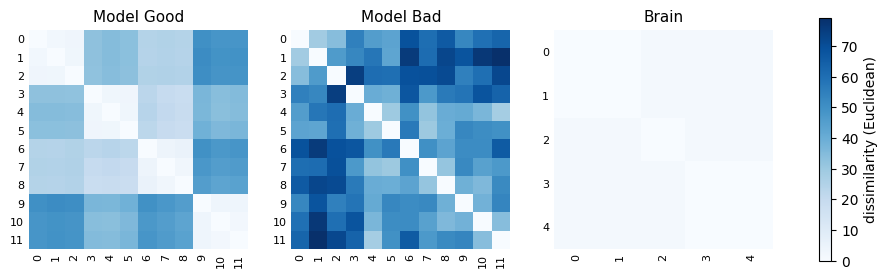

In [26]:
rdms_from_dataset = [rdm_good, rdm_bad, rdm_brain]
titles_from_dataset = ['Model Good', 'Model Bad', 'Brain']
plot_rdms(rdms_from_dataset, titles_from_dataset)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

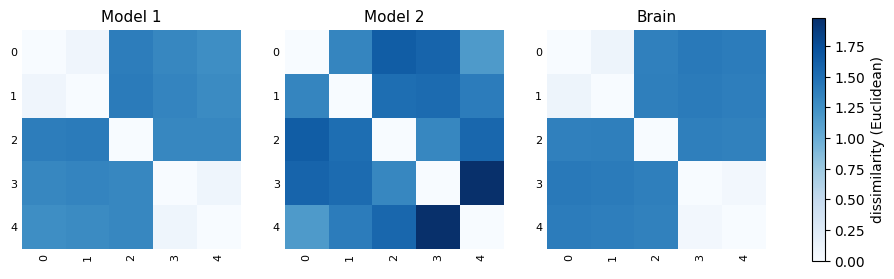

In [28]:
rdms = [rdm1, rdm2, rdm_brain]
titles = ['Model 1', 'Model 2', 'Brain']
plot_rdms(rdms, titles)
plt.show

## Step 6: Generalize your toolbox

### Support additional dissimilarity metrics in compute_rdm()

In [29]:
# Dissimilarity metrix for computing RDM
def compute_rdm_eucledian(patterns: np.ndarray) -> np.ndarray:
    """Compute the Euclidean-distance RDM for a set of representational patterns."""
    n_classes = patterns.shape[0]
    rdm = np.zeros((n_classes, n_classes))

    # Construct the RDM by computing pairwise distances between patterns
    for i in range(n_classes):
        for j in range(i+1, n_classes):
            rdm[i, j] = np.linalg.norm(patterns[i] - patterns[j])
            rdm[j, i] = rdm[i,j]
    return rdm

def compute_rdm_1correlation(patterns: np.ndarray) -> np.ndarray:
    """Compute the 1-correlation RDM for a set of representational patterns."""
    n_classes = patterns.shape[0]
    rdm = np.zeros((n_classes, n_classes))

    # Construct the RDM by computing pairwise distances between patterns
    for i in range(n_classes):
        for j in range(i+1, n_classes):
            rdm[i, j] = 1 - np.corrcoef(patterns[i], patterns[j])[0, 1]
            rdm[j, i] = rdm[i,j]
    return rdm

### Support Spearman's rank correlation as an alternative to Pearson in compare_rdms()

In [31]:
def upper_triangle(rdm: np.ndarray) -> np.ndarray:
    """Extract the off-diagonal upper-triangular entries of an RDM as a 1D vector."""
    
    return rdm[np.triu_indices(rdm.shape[0], k=1)]
    

def compare_rdms_pcc_custom(rdm_a: np.ndarray, rdm_b: np.ndarray) -> float:
    """Compare two RDMs via Pearson correlation of their upper-triangular entries."""
    rdm_a = upper_triangle(rdm_a)
    rdm_b = upper_triangle(rdm_b)
    
    mean_a = np.mean(rdm_a)
    mean_b = np.mean(rdm_b)
    
    var_a = np.var(rdm_a)
    var_b = np.var(rdm_b)
    
    numerator = np.mean((rdm_a - mean_a)*(rdm_b - mean_b))
    denominator = np.sqrt(var_a*var_b)
    return numerator/denominator

def compare_rdms_pcc(rdm_a: np.ndarray, rdm_b: np.ndarray) -> float:
    """Compare two RDMs via Pearson correlation of their upper-triangular entries."""
    rdm_a = upper_triangle(rdm_a)
    rdm_b = upper_triangle(rdm_b)
    return np.corrcoef(rdm_a, rdm_b)[0, 1]

def compare_rdms_spearman(rdm_a: np.ndarray, rdm_b: np.ndarray) -> float:
    """Compare two RDMs via Spearman correlation of their upper-triangular entries."""
    rdm_a = upper_triangle(rdm_a)
    rdm_b = upper_triangle(rdm_b)
    return spearmanr(rdm_a, rdm_b).correlation


### compare_to_many(reference_rdm, candidate_rdms) function

In [32]:
# compare_to_many(reference_rdm, candidate_rdms) function that compares one reference RDM against a list of candidate RDMs and returns a ranked list of similarities
def compare_to_many(reference_rdm: np.ndarray, candidate_rdms: list) -> list:
    """Compare one reference RDM against a list of candidate RDMs and return a ranked list of similarities."""
    similarities = []
    for candidate_rdm in candidate_rdms:
        similarity = compare_rdms_pcc(reference_rdm, candidate_rdm)
        similarities.append(similarity)
    
    # Rank the similarities in descending order
    ranked_indices = np.argsort(similarities)[::-1]
    ranked_similarities = [(i, similarities[i]) for i in ranked_indices]
    
    return ranked_similarities

### Statistical tests